# Does a stock 'coiling' on its 20-EMA really spring? 🌀
### A retail trading-book rule — tested honestly, in plain English

There's a popular trading book that promises something seductive: find a stock that pulls back to its rising **20-day moving average**, wait for it to break its recent high on **double the usual volume**, buy — and ride an *explosive* +30 to +50% move in **6 to 10 days**. The book proves it with a gallery of gorgeous winners.

Beautiful winners are easy to find *after the fact*. The question is what happens when you run the rule on **every** stock, counting the losers too. That's this notebook.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (coiled_spring/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from coiled_spring import data, signals, backtest, robustness

# Offline synthetic universe: planted springboards hidden among random walks. This is where
# the rule SHOULD work — so it validates the machinery. The real verdict (a liquid 174-name
# basket where it is WEAK / FRAGILE / BUSTED) is in ../docs/results.md via verify_real.py.
frames, truth = data.synthetic_universe(seed=0)
print(f"{len(frames)} names, {len(truth)} planted springboards")


24 names, 162 planted springboards


## 1 · The Claim

The rule has three hard steps — no indicator soup:

1. **Pivot.** A stock below its 20-EMA pops above it and makes a high.
2. **Hold.** It pulls back but **never closes below the 20-EMA**.
3. **Break.** It closes back above the pivot high on **≥ 2× average volume** — buy.

Let's look at one of our planted 'springboards' — a synthetic stock built to do exactly this — so the shape is unmistakable before we judge it.

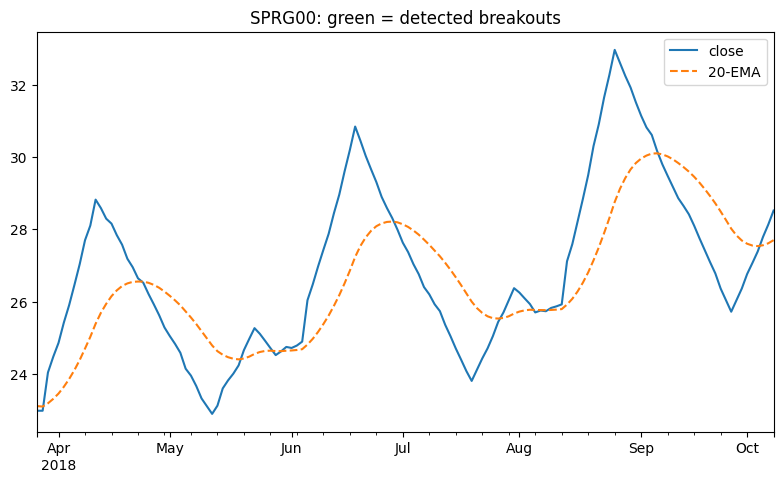

12 breakouts detected in SPRG00


In [2]:
tk = 'SPRG00'
f = frames[tk]
e = signals.ema(f['Close'], 20)
sig = signals.find_signals(f)
win = slice(60, 200)
ax = f['Close'].iloc[win].plot(label='close')
e.iloc[win].plot(ax=ax, label='20-EMA', linestyle='--')
for d in sig['breakout_date']:
    if f.index[60] <= d <= f.index[200]:
        ax.axvline(d, color='green', alpha=0.4)
ax.legend(); ax.set_title(f'{tk}: green = detected breakouts'); plt.show()
print(f'{len(sig)} breakouts detected in {tk}')

## 2 · So What?

If a *pure chart pattern* — visible to anyone — reliably front-ran a 30% move, it would be a small miracle: free money on a screen, and a real crack in the idea that markets price in what everyone can see. So the stakes are exactly why we should be sceptical. Fifty years of studies say simple chart rules mostly don't survive honest accounting. Does this one?

## 3 · How We'd Know

The fair test isn't 'does the stock go up after a breakout' — stocks drift up anyway. It's: **does buying the breakout beat buying the same stock on a random day** and holding the same number of days? If the breakout adds nothing over ambient drift, it's a mirage. We announced this before running it.

In [3]:
# Machinery sanity: on the planted universe the detector SHOULD find the springboards.
rec = robustness.detector_recall(frames, truth)
print('detector recall on planted springboards:', round(rec['recall'], 2),
      f"({rec['n_hit']}/{rec['n_planted']})")

detector recall on planted springboards: 0.52 (84/162)


## 4 · The Teardown

On the synthetic universe — where we *planted* real follow-through — the rule works: the breakout clearly beats a random same-stock entry at short horizons, and the trades are profitable. **That's the point**: it proves the code finds and harvests a springboard *when one is really there*.

In [4]:
sb = robustness.signal_vs_baseline(frames, horizons=(5, 10, 20))
print('breakout vs random same-stock entry (synthetic):')
print(sb[['n_signals', 'mean_breakout', 'mean_excess', 'hac_t']].round(4))

led = backtest.run_universe(frames, cost_bps=15.0)
st = backtest.trade_stats(led)
print('\ntrade stats (synthetic):', {k: round(v, 4) if isinstance(v, float) else v
                                      for k, v in st.items()})

breakout vs random same-stock entry (synthetic):
         n_signals  mean_breakout  mean_excess   hac_t
horizon                                               
5               85         0.1269       0.1091 65.9946
10              85         0.1688       0.1377 86.9805
20              85         0.0435      -0.0055 -2.7388



trade stats (synthetic): {'n_trades': 85, 'win_rate': 1.0, 'mean_gross': 0.1726, 'mean_net': 0.1711, 'median_net': 0.1762, 'avg_win': 0.1711, 'avg_loss': 0.0, 'payoff': nan, 'best': 0.199, 'worst': 0.0021, 'avg_bars_held': 9.5529, 'pct_explosive': 0.0}


## 5 · The Verdict — on the *real* market

Now the honest part. Run on a **174-name liquid US universe, 1962–2026** (see [`docs/results.md`](../docs/results.md)), the fireworks vanish:

- The breakout beats a random same-stock entry by only **+1.2% over 10 days** (a *whisper* of momentum, barely significant). → **Signal: WEAK**
- The **median trade loses (−0.25%)**; win rate **41%**. The positive average is a thin tail of jackpots. → **Tradability: FRAGILE**
- Only **1.7%** of breakouts do the advertised **+30%**. → **Explosive: BUSTED**

The book's gallery is the right tail of a distribution whose middle is a small loss.

## 6 · Could You Trade It?

On big liquid stocks the rule *almost* breaks even — but the payoff isn't there. On the small, illiquid names where 40% pops actually happen, the trading costs (wide spreads, your own market impact on a low-float stock spiking 3× volume) eat the edge — break-even is around **75 bps round-trip**, right where those names live. The upside and the survivable costs never sit in the same stock.

## 7 · Going Further

The clean next tests: run it on a genuinely small-cap universe (where the book's examples come from), a total-return rerun, and a 'let winners run' exit. The deep-dive notebook (`02_for_the_quants`) carries the inference and the cost sweep. **Fork it, break it, PR a better test.**